## Import setup & Configuration

In [18]:
import warnings
warnings.filterwarnings("ignore")
import os
from pathlib import Path
from langchain_community.document_loaders import PyPDFLoader

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import PromptTemplate
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_huggingface import HuggingFaceEmbeddings, HuggingFaceEndpoint

In [19]:
from dotenv import load_dotenv

ENV_PATH = Path.cwd().parent.parent / ".env"
load_dotenv(dotenv_path=ENV_PATH)

# Configuration for HF
HF_TOKEN = os.getenv("HF_TOKEN")
HF_HOME = os.getenv("HF_HOME")
HF_ENDPOINT_URL = os.getenv("HF_ENDPOINT_URL")
print(f"Loaded for HF: {HF_TOKEN is not None}, {HF_HOME is not None}, {HF_ENDPOINT_URL is not None}")

Loaded for HF: True, True, True


## Load PDF Dataset

In [20]:
# Confguration
PDF_GEN_AI_BANKING = Path("../../Database/PDF/Generative AI and LLMs in Banking.pdf")
PDF_ML_APPLICATIONS = Path("../../Database/PDF/Machine-Learning-Applications Journal.pdf")
PDF_BANK_JOURNAL = Path("../../Database/PDF/Bank-Journal.pdf")

# Load PDF
for pdf_path in [PDF_GEN_AI_BANKING, PDF_ML_APPLICATIONS, PDF_BANK_JOURNAL]:
    if pdf_path.exists():
        loader = PyPDFLoader(str(pdf_path))
        documents = loader.load()
        print(f"Loaded {len(documents)} pages from {pdf_path.name}")
    else:
        print(f"File {pdf_path} does not exist.")

Gen_AI_Banking = PyPDFLoader(str(PDF_GEN_AI_BANKING)).load() # Use cases GenAI and LLMs in Banking
ML_applications = PyPDFLoader(str(PDF_ML_APPLICATIONS)).load() # ML In Banking applications e.g. -> Fraudm, Market risk, Credit risk
Bank_Journal = PyPDFLoader(str(PDF_BANK_JOURNAL)).load() # Predict customer churn in the banking sector - [Optional] to prevent customer churn

Loaded 13 pages from Generative AI and LLMs in Banking.pdf
Loaded 14 pages from Machine-Learning-Applications Journal.pdf
Loaded 16 pages from Bank-Journal.pdf


In [21]:
# Page content preview for Generative AI and LLMs in Banking
for doc in Gen_AI_Banking:
    print(f"Doc page for {PDF_GEN_AI_BANKING.name}:")
    print(doc.page_content[:500]) 
    print("-" * 80)

for doc in ML_applications:
    print(f"Doc page for {PDF_ML_APPLICATIONS.name}:")
    print(doc.page_content[:500]) 
    print("-" * 80)

for doc in Bank_Journal:
    print(f"Doc page for {PDF_BANK_JOURNAL.name}:")
    print(doc.page_content[:500]) 
    print("-" * 80)



Doc page for Generative AI and LLMs in Banking.pdf:
Generative AI and LLMs in 
Banking: Examples, Use Cases, 
Limitations, and Solutions 
 
Banking may not seem like the most technologically progressive industry. But it isn’t 
slow; it’s just very cautious. If we look at the tech evolution of financial institutions, 
we’ll see they are riding the tech wave—with a life jacket on. We’ve witnessed this slow 
adoption of new developments with online banking, cloud services, and paying with an 
Apple Watch.  
Artificial intelligence is the latest tech
--------------------------------------------------------------------------------
Doc page for Generative AI and LLMs in Banking.pdf:
We’re not here to aggressively push bank executives into the uncharted waters of 
GenAI or, more specifically, large language models (LLMs)—that’s not our style. What 
we want to do is give you the information to make an informed decision. So stay tuned 
to learn more details about the use cases of generative AI 

## Load data parquet (EDA Banking)

In [22]:
import pandas as pd

def load_data(file_path):
    if file_path.exists():
        return pd.read_parquet(file_path)
    else:
        print(f"File {file_path} does not exist.")
        return None
    
# load
pd.set_option('display.max_columns', None)  # Show all columns
df = load_data(Path("../../Database/data/eda_banking.parquet"))
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,Fraud,RiskScore,BalancePerProduct,AgeRisk,HighValueCustomer,LowCreditRisk,MarketingScore,ComplainFlag,LowSatisfaction,OperationalRiskScore
0,619,France,Female,42,2,11983969.0,1,1,1,10134888.0,1,1,2,DIAMOND,464,0,1,0.000000,0,0,0,0,1,1,2
1,608,Spain,Female,41,1,8380786.0,1,0,1,11254258.0,0,1,3,DIAMOND,456,0,1,41903.930000,0,0,0,1,1,0,1
2,502,France,Female,42,8,15966080.0,3,1,0,11393157.0,1,1,3,DIAMOND,377,0,3,39915.200000,0,1,0,1,1,0,2
3,699,France,Female,39,1,11983969.0,2,0,0,9382663.0,0,0,5,GOLD,350,0,1,0.000000,0,0,0,0,0,0,1
4,850,Spain,Female,43,2,12551082.0,1,1,1,7908410.0,0,0,5,GOLD,425,0,1,62755.410000,0,1,0,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,11983969.0,2,1,0,9627064.0,0,0,1,DIAMOND,300,0,1,0.000000,0,0,0,0,0,1,2
9996,516,France,Male,35,10,5736961.0,1,1,1,10169977.0,0,0,5,PLATINUM,771,0,0,28684.805000,0,0,0,0,0,0,0
9997,709,France,Female,36,7,11983969.0,1,0,1,4208558.0,1,1,3,SILVER,564,0,1,0.000000,0,0,0,0,1,0,1
9998,772,Germany,Male,42,3,7507531.0,2,1,0,9288852.0,1,1,2,GOLD,339,1,2,25025.103333,0,0,0,1,1,1,3


## Dataframe summary

In [23]:
def dataframe_summary(df: pd.DataFrame) -> str:
    lines = []
    lines.append(f"Dataset: {len(df)} rows, {df.shape[1]} columns")

    # Key rates
    for col, label in [
        ("Exited", "Churn Rate"),
        ("Fraud", "Fraud Rate"),
        ("Complain", "Complain Rate"),
        ("HighValueCustomer", "High Value Customer %"),
        ("LowCreditRisk", "Low Credit Risk %"),
        ("LowSatisfaction", "Low Satisfaction %")
    ]:
        
        if col in df.columns:
            lines.append(f"{label}: {df[col].mean() * 100:.2f}%")

    # Numerical stats
    num_cols = [
        "CreditScore", "Age", "Balance", "EstimatedSalary",
        "RiskScore", "BalancePerProduct", "MarketingScore",
        "OperationalRiskScore", "Point Earned", "Satisfaction Score"
    ]
    existing = [c for c in num_cols if c in df.columns]
    lines.append(f"\nNumerical Summary:\n{df[existing].describe().round(2).to_string()}")

    # Categorical distribution
    for col in ["Geography", "Gender", "Card Type"]:
        if col in df.columns:
            lines.append(f"\n{col}:\n{df[col].value_counts().to_string()}")

    return "\n".join(lines)

df_summary = dataframe_summary(df)
print(df_summary)

Dataset: 10000 rows, 25 columns
Churn Rate: 20.38%
Fraud Rate: 3.32%
Complain Rate: 20.44%
High Value Customer %: 47.99%
Low Credit Risk %: 6.32%
Low Satisfaction %: 39.46%

Numerical Summary:
       CreditScore       Age      Balance  EstimatedSalary  RiskScore  BalancePerProduct  MarketingScore  OperationalRiskScore  Point Earned  Satisfaction Score
count     10000.00  10000.00     10000.00         10000.00   10000.00           10000.00        10000.00              10000.00      10000.00            10000.00
mean        650.53     38.92  11983190.52      10009023.99       1.23           33603.67            1.04                  1.08        606.52                3.01
std          96.65     10.49   2404336.73       5751049.28       0.92           28665.63            0.81                  0.85        225.92                1.41
min         350.00     18.00    376869.00          1158.00       0.00               0.00            0.00                  0.00        119.00                1.00
25

In [24]:
from tqdm import tqdm

# Load pdfs
PDF_PATHS = [PDF_GEN_AI_BANKING, PDF_ML_APPLICATIONS, PDF_BANK_JOURNAL]

all_docs = []

for path in tqdm(PDF_PATHS, desc="Loading PDFs", unit="file"):
    loader = PyPDFLoader(path)
    docs = loader.load()
    for doc in docs:
        doc.metadata["source"] = Path(path).name
    all_docs.extend(docs)
    tqdm.write(f"{Path(path).name} - Loaded {len(docs)} pages")

print(f"Total documents loaded: {len(all_docs)}")

Loading PDFs:  33%|███▎      | 1/3 [00:00<00:00,  7.87file/s]

Generative AI and LLMs in Banking.pdf - Loaded 13 pages


Loading PDFs:  67%|██████▋   | 2/3 [00:00<00:00,  3.68file/s]

Machine-Learning-Applications Journal.pdf - Loaded 14 pages


Loading PDFs: 100%|██████████| 3/3 [00:00<00:00,  3.61file/s]

Bank-Journal.pdf - Loaded 16 pages
Total documents loaded: 43


## Split into Chunks

In [25]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=100,
    separators=["\n\n", "\n", ".", " "],
)

chunks = []
for doc in tqdm(all_docs, desc="Splitting documents into chunks", unit="doc"):
    chunks.extend(splitter.split_documents([doc]))

print(f"Total chunks: {len(chunks)}")
print(f"\nSample chunk:\n{chunks[0].page_content[:300]}")

Splitting documents into chunks: 100%|██████████| 43/43 [00:00<00:00, 14750.56doc/s]

Total chunks: 182

Sample chunk:
Generative AI and LLMs in 
Banking: Examples, Use Cases, 
Limitations, and Solutions 
 
Banking may not seem like the most technologically progressive industry. But it isn’t 
slow; it’s just very cautious. If we look at the tech evolution of financial institutions, 
we’ll see they are riding the tec


## Embedding + FAISS Vector Store

In [26]:
import torch

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "mps" if torch.backends.mps.is_available() else "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)

vectorstore = FAISS.from_documents(chunks, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

In [27]:
from huggingface_hub import InferenceClient
from tqdm import tqdm

client = InferenceClient(token=HF_TOKEN)

test_models = [
    "meta-llama/Meta-Llama-3-8B-Instruct",
    "google/gemma-7b-it",
    "microsoft/Phi-2",
    "deepseek-ai/deepseek-coder-6.7b-instruct",
]

for model in tqdm(test_models, desc="🔍 Testing models"):
    try:
        resp = client.chat_completion(
            model=model,
            messages=[{"role": "user", "content": "Say hello."}],
            max_tokens=10,
        )
        tqdm.write(f"  ✅ {model} — works")
    except Exception as e:
        tqdm.write(f"  ❌ {model} — {str(e)[:80]}")

🔍 Testing models: 100%|██████████| 4/4 [00:01<00:00,  3.90it/s]

  ✅ meta-llama/Meta-Llama-3-8B-Instruct — works
  ❌ google/gemma-7b-it — 
  ❌ microsoft/Phi-2 — 
  ❌ deepseek-ai/deepseek-coder-6.7b-instruct — 


## LLM Setup

In [28]:
from huggingface_hub import InferenceClient

client = InferenceClient(
    model="meta-llama/Meta-Llama-3-8B-Instruct",
    token=HF_TOKEN,
)

print("InferenceClient ready for Meta-Llama-3-8B-Instruct")

InferenceClient ready for Meta-Llama-3-8B-Instruct


## Prompt template

In [29]:
def build_prompt(context: str, question: str, df_context: str) -> str:
    return f"""You are a senior banking data scientist and AI consultant.
    You have access to research literature on AI/ML in banking and a real dataset summary below.
    
=== DATASET SUMMARY ===
{df_context}
=== END DATASET SUMMARY ===

=== RESEARCH CONTEXT ===
{context}
=== END RESEARCH CONTEXT ===

Question: {question}

Answer (be specific, reference dataset metrics when relevant):"""

print("Prompt template ready")

Prompt template ready


## LCEL RAG Chain

In [30]:
def format_docs(docs):
    return "\n\n".join(d.page_content for d in docs)

# Function to ask a question
def ask(question: str) -> str:
    """Run a question through the RAG chain and print a formatted result."""
    print(f"{'='*60}")
    print(f"📌 Q: {question.strip()}")
    print(f"{'='*60}")

    # Step 1: Retrieve relevant chunks
    source_docs = retriever.invoke(question)
    context = format_docs(source_docs)

    # Step 2: Build the prompt
    prompt = build_prompt(
        context=context,
        question=question.strip(),
        df_context=df_summary
    )

    # Step 3: Call LLM via conversational task
    response = client.chat_completion(
        messages=[{"role": "user", "content": prompt}],
        max_tokens=512,
        temperature=0.3
    )

    # Step 4: Extract and print the answer
    answer = response.choices[0].message.content.strip()
    print(f"🤖 A: {answer}\n")

    # Show sources PDFs
    sources = list({d.metadata.get("source", "Unknown") for d in source_docs})
    print(f"📚 Sources: {', '.join(sources)}\n")

    return answer

print("RAG chain ready. You can now ask questions using the `ask()` function.")

RAG chain ready. You can now ask questions using the `ask()` function.


## Insight 1 -> Customer Churn

In [31]:
answer_churn = ask("""
What are the main drivers of customer churn based on features like
RiskScore, Satisfaction Score, Complain, IsActiveMember, and BalancePerProduct?
What ML models do the papers recommend for churn prediction with imabalanced data?""")

📌 Q: What are the main drivers of customer churn based on features like
RiskScore, Satisfaction Score, Complain, IsActiveMember, and BalancePerProduct?
What ML models do the papers recommend for churn prediction with imabalanced data?
🤖 A: Based on the provided dataset and research context, the main drivers of customer churn can be identified as follows:

1. **RiskScore**: The mean RiskScore is 1.23, indicating that most customers have a relatively low risk profile. However, the standard deviation is 0.92, suggesting that there is a significant variation in risk scores among customers. A higher RiskScore might indicate a higher likelihood of churn, as customers with higher risk profiles may be more likely to switch banks due to dissatisfaction or financial difficulties.

2. **Satisfaction Score**: The mean Satisfaction Score is 3.01, indicating that customers are generally satisfied with their banking services. However, the standard deviation is 1.41, suggesting that there is a signifi

## Insight 2 -> Fraud Detection

In [32]:
answer_fraud = ask("""
The dataset has a Fraud column alongside RiskScore and OperationalRiskScore.
What ML and LLM approaches do the research papers recommend for fraud detection?
How can GenAI improve real-time fraud flagging pipelines in banking?""")

📌 Q: The dataset has a Fraud column alongside RiskScore and OperationalRiskScore.
What ML and LLM approaches do the research papers recommend for fraud detection?
How can GenAI improve real-time fraud flagging pipelines in banking?
🤖 A: Based on the research context and the provided dataset, the following ML and LLM approaches are recommended for fraud detection:

1. **Gradient Boosting Machines (XGBoost and LightGBM)**: These ensemble methods are particularly effective in detecting anomalies and are recommended for models of probability of default, loss given default, and exposure at default (Robisco & Martínez, 2022; Alamsyah et al., 2025).
2. **Graph Neural Networks**: These can be used to analyze transaction networks and uncover money laundering rings (Dichev et al., 2020).
3. **Pattern Recognition**: This is central to ML and can be efficient in fraud detection and anti-money laundering (AML) (Dichev et al., 2020).
4. **Anomaly Detection Algorithms**: These can detect anomalous ac

## Insight 3 -> GenAI Use Cases

In [33]:
answer_genai = ask("""
Given features like MarketingScore, HighValueCustomer, LowSatisfaction,
CardType, and Point Earned, which GenAI and LLM use cases from the
research papers are most applicable and deliver the highest ROI for banks?""")

📌 Q: Given features like MarketingScore, HighValueCustomer, LowSatisfaction,
CardType, and Point Earned, which GenAI and LLM use cases from the
research papers are most applicable and deliver the highest ROI for banks?
🤖 A: Based on the provided research context and dataset summary, I would recommend the following GenAI and LLM use cases that are most applicable and deliver the highest ROI for banks:

1. **Fraud Detection and Prevention**: With a Fraud Rate of 3.32%, banks can leverage GenAI and LLMs to improve the accuracy and efficiency of fraud detection. The use of natural language processing (NLP) and machine learning algorithms can help identify patterns and anomalies in customer behavior, reducing the risk of fraudulent activities. According to KPMG, 76% of banking executives in the US plan to use generative AI for fraud detection and prevention, indicating a high potential ROI.

2. **Customer Service**: With a Low Satisfaction Rate of 39.46%, banks can use GenAI and LLMs to imp

## Insight 4 -> Risk & Explainability

In [34]:
answer_risk = ask("""
Our dataset includes RiskScore, LowCreditRisk, AgeRisk, and OperationalRiskScore.
What do the ML model risk management papers recommend for validating these scores
in regulated banking environments? which explainability techniques (SHAP, LIME)
are most suitable for explaining model predictions to stakeholders and regulators?""")

📌 Q: Our dataset includes RiskScore, LowCreditRisk, AgeRisk, and OperationalRiskScore.
What do the ML model risk management papers recommend for validating these scores
in regulated banking environments? which explainability techniques (SHAP, LIME)
are most suitable for explaining model predictions to stakeholders and regulators?
🤖 A: Based on the research context and the provided dataset, we can infer the following recommendations for validating the RiskScore, LowCreditRisk, AgeRisk, and OperationalRiskScore in regulated banking environments.

**Validation of RiskScore:**

The ML model risk management papers recommend the following validation methods for RiskScore:

1. **Drift monitoring**: Regularly monitor the RiskScore for changes in its distribution over time to ensure it remains accurate and reliable (Bank of England, 2023).
2. **Bias detection**: Use techniques such as bias noise detection formulations to identify and mitigate biases in the RiskScore (Misheva et al., 2021).
3. *

## Insight 5 -> Customer Segmentation

In [35]:
answer_segment = ask("""
Using features like HighValueCustomer, MarketingScore, EstimatedSalary,
Card Type, and Point Earned - what customer segmentation strategies do the papers recommend
for AI-powered retention and personalized banking services?""")

📌 Q: Using features like HighValueCustomer, MarketingScore, EstimatedSalary,
Card Type, and Point Earned - what customer segmentation strategies do the papers recommend
for AI-powered retention and personalized banking services?
🤖 A: Based on the provided research context and dataset summary, I will outline customer segmentation strategies for AI-powered retention and personalized banking services.

1. **Segmentation by Customer Lifetime Value (CLV)**: The papers emphasize the significance of CLV as a foundational construct for designing effective churn reduction strategies [10]. To calculate CLV, we can use features like EstimatedSalary, Balance, and Point Earned. We can create a CLV score by multiplying the average transaction value by the customer's lifetime, which can be estimated using the customer's age and average transaction frequency.

   **Recommendation**: Use a combination of EstimatedSalary, Balance, and Point Earned to create a CLV score, and segment customers into high-v

## Export report to markdown

In [36]:
question_answer = {
    "Customer Churn Drivers & Prediction": answer_churn,
    "Fraud Detection with ML & LLMs": answer_fraud,
    "GenAI Use Cases for Banking": answer_genai,
    "Risk Score Validation & Explainability": answer_risk,
    "Customer Segmentation Strategy": answer_segment
}

churn_rate = df["Exited"].mean() * 100
fraud_rate = df["Fraud"].mean() * 100

report = [
    "# 🏦 Banking AI Insights Report",
    f"\n**Dataset:** {df.shape[0]:,} rows, {df.shape[1]} columns",
    f"**Churn Rate:** {churn_rate:.2f}% | **Fraud Rate:** {fraud_rate:.2f}%\n",
    "---\n"
]

for i, (title, answer) in enumerate(tqdm(question_answer.items(), desc="📝 Writing Report", unit="insight"), 1):
    report.append(f"## Insight {i}: {title}\n")
    report.append(answer.strip())
    report.append("\n\n---\n")
    tqdm.write(f"Insight {i} written: {title}")

output_path = Path("Banking_llm_insights_report.md")
output_path.write_text("\n".join(report), encoding="utf-8")

print(f"\n Report Saved -> {output_path.resolve()}")

📝 Writing Report: 100%|██████████| 5/5 [00:00<00:00, 858.26insight/s]

Insight 1 written: Customer Churn Drivers & Prediction
Insight 2 written: Fraud Detection with ML & LLMs
Insight 3 written: GenAI Use Cases for Banking
Insight 4 written: Risk Score Validation & Explainability
Insight 5 written: Customer Segmentation Strategy

 Report Saved -> /Users/miftahhadiyannoor/Documents/Bank-Project/ml-engineer/notebooks/Banking_llm_insights_report.md


## Data visualization

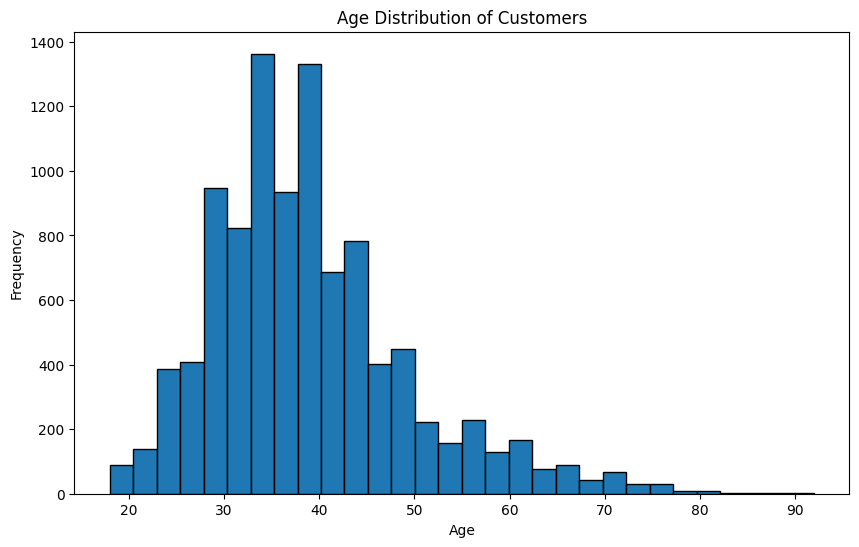

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=30, edgecolor='k')
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

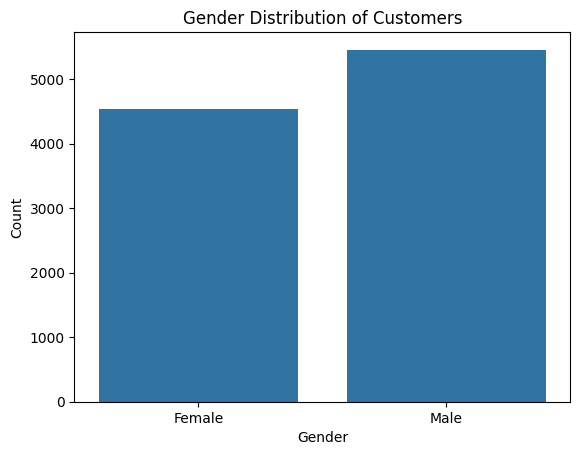

In [38]:
plt.Figure(figsize=(10, 6))
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution of Customers')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

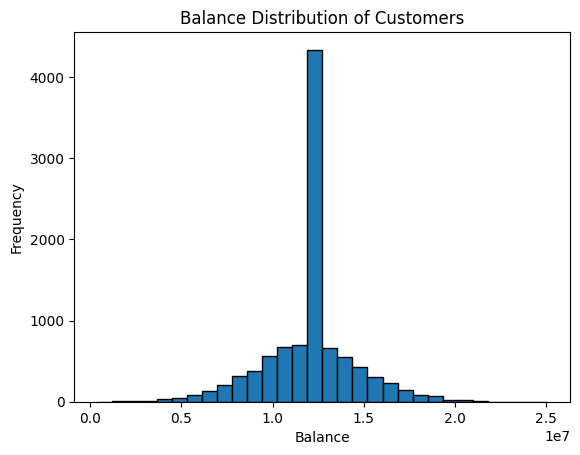

In [39]:
plt.Figure(figsize=(10, 6))
plt.hist(df[['Balance']], bins=30, edgecolor='k')
plt.title('Balance Distribution of Customers')
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.show()